import required libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [29]:
df=pd.read_csv("C:\Tekworks\Day 17\knn_regression_dataset.csv")
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [30]:
df.dtypes

age                  int64
income             float64
loan_amount        float64
credit_score       float64
city                object
employment_type     object
target             float64
dtype: object

In [31]:
df.info

<bound method DataFrame.info of      age        income    loan_amount  credit_score       city  \
0     56  25903.305196  286348.192562    789.476075    Chennai   
1     69  53051.954538  180018.190719    596.334039    Chennai   
2     46  38654.738821  211234.236288    611.531000    Chennai   
3     32  28666.194356  246629.541594    710.171152    Chennai   
4     60  40301.406736  129081.713353    622.900855  Hyderabad   
..   ...           ...            ...           ...        ...   
995   60           NaN  272663.033166    502.604714    Chennai   
996   64  36687.617333  133069.710014    730.751324  Bangalore   
997   62  43438.125495  234645.931152    747.044458  Hyderabad   
998   35  60835.720367  169706.958962    628.847359  Bangalore   
999   55  44407.502719  285968.895310    467.780404    Chennai   

    employment_type         target  
0          Salaried  158793.631698  
1          Salaried  115596.093965  
2          Salaried  127231.057638  
3        Unemployed  145102

In [32]:
df.describe

<bound method NDFrame.describe of      age        income    loan_amount  credit_score       city  \
0     56  25903.305196  286348.192562    789.476075    Chennai   
1     69  53051.954538  180018.190719    596.334039    Chennai   
2     46  38654.738821  211234.236288    611.531000    Chennai   
3     32  28666.194356  246629.541594    710.171152    Chennai   
4     60  40301.406736  129081.713353    622.900855  Hyderabad   
..   ...           ...            ...           ...        ...   
995   60           NaN  272663.033166    502.604714    Chennai   
996   64  36687.617333  133069.710014    730.751324  Bangalore   
997   62  43438.125495  234645.931152    747.044458  Hyderabad   
998   35  60835.720367  169706.958962    628.847359  Bangalore   
999   55  44407.502719  285968.895310    467.780404    Chennai   

    employment_type         target  
0          Salaried  158793.631698  
1          Salaried  115596.093965  
2          Salaried  127231.057638  
3        Unemployed  1451

In [33]:
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [35]:
#handled missing values by filling them with median values
# find the median values of the credit score and income columns and loan amount

# Find median values
median_credit_score = df['credit_score'].median()
median_income = df['income'].median()
median_loan_amount = df['loan_amount'].median()

print("Median Credit Score:", median_credit_score)
print("Median Income:", median_income)
print("Median Loan Amount:", median_loan_amount)

# Fill missing values with median
df['credit_score'].fillna(median_credit_score, inplace=True)
df['income'].fillna(median_income, inplace=True)
df['loan_amount'].fillna(median_loan_amount, inplace=True)

print("\nMissing values handled using median.")

Median Credit Score: 649.9780429171758
Median Income: 51119.92518950612
Median Loan Amount: 200190.69362932903

Missing values handled using median.


In [36]:
import warnings
warnings.filterwarnings("ignore")

In [53]:
# Columns to check for outliers
columns = ['age', 'income', 'loan_amount', 'credit_score']

def cap_outlier(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Handling outliers by capping
    df[col] = df[col].clip(lower_limit, upper_limit)

print("Outliers handled for each column.")
print(df.describe())

Outliers handled for each column.
              age        income    loan_amount  credit_score         target
count  1000.00000   1000.000000    1000.000000   1000.000000    1000.000000
mean     43.81900  51594.786288  202628.711261    649.441836  125258.332699
std      14.99103  15449.568322   49913.878015     69.578959   31423.294558
min      18.00000  12324.443195   72608.473571    466.114804   40800.918241
25%      31.00000  41333.003531  169682.444383    602.718549  105707.679044
50%      44.00000  51119.925190  200190.693629    649.978043  123651.542971
75%      56.00000  60672.043755  234398.424924    693.787712  141801.468844
max      69.00000  89680.604092  331472.395735    830.391457  333440.450713


In [54]:
#check the size of outliers in each column
    # Count outliers

# Columns to check
columns = ['age', 'income', 'loan_amount', 'credit_score']

def cap_outlier(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    print(f"{col} column outliers count:", outliers.shape[0])

In [55]:
#handling outliers by capping function
# Capping outliers
df[col] = df[col].clip(lower_limit, upper_limit)

print("Outliers handled using capping method.")
print(df.head())

Outliers handled using capping method.
   age        income    loan_amount  credit_score       city employment_type  \
0   56  25903.305196  286348.192562    789.476075    Chennai        Salaried   
1   69  53051.954538  180018.190719    596.334039    Chennai        Salaried   
2   46  38654.738821  211234.236288    611.531000    Chennai        Salaried   
3   32  28666.194356  246629.541594    710.171152    Chennai      Unemployed   
4   60  40301.406736  129081.713353    622.900855  Hyderabad      Unemployed   

          target  
0  158793.631698  
1  115596.093965  
2  127231.057638  
3  145102.187078  
4  110623.128404  


In [56]:
df[col]=df[col].clip(lower_limit, upper_limit)
df[col]

0      789.476075
1      596.334039
2      611.531000
3      710.171152
4      622.900855
          ...    
995    502.604714
996    730.751324
997    747.044458
998    628.847359
999    467.780404
Name: credit_score, Length: 1000, dtype: float64

In [57]:
cap_outlier("credit_score")
cap_outlier("loan_amount")
cap_outlier("income")

credit_score column outliers count: 0
loan_amount column outliers count: 0
income column outliers count: 0


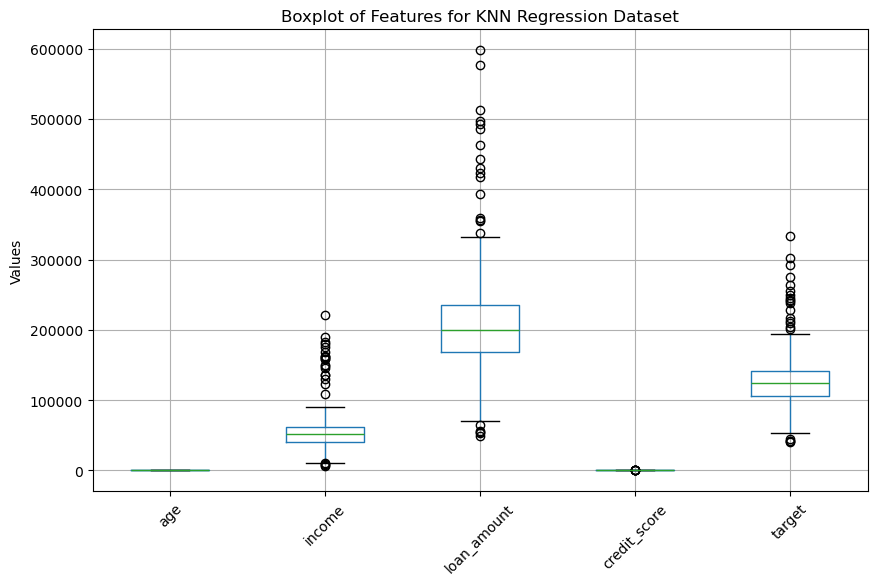

In [ ]:
# Select only numerical columns used in KNN
numerical_features = ['age', 'income', 'loan_amount', 'credit_score', 'target']
# Create boxplot
plt.figure(figsize=(10,6))
df[numerical_features].boxplot()

plt.title("Boxplot of Features for KNN Regression Dataset")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.show()

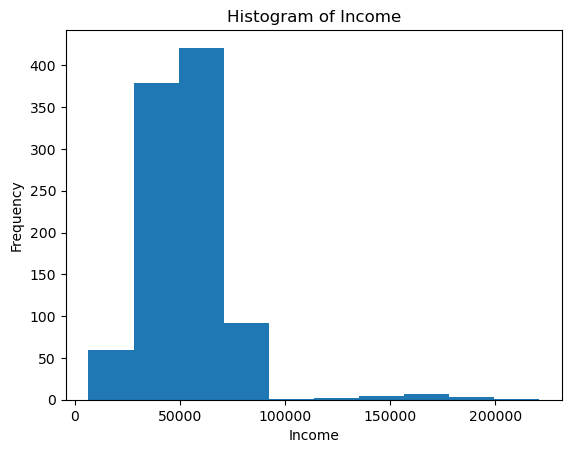

In [13]:
plt.hist(df['income'], bins=10)
plt.title("Histogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [58]:
df.shape

(1000, 7)

In [ ]:
# check the employee_type column value counts
df['employment_type'].value_counts()

employment_type
Self-Employed    356
Salaried         325
Unemployed       319
Name: count, dtype: int64

In [69]:
# handled the categorical variables by one hot encoding

cat = ['city', 'employment_type']

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(df[cat])

# Convert encoded data into a DataFrame
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat))

# Merge encoded columns with original dataset
df = pd.concat([df.drop(columns=cat), encoded_df], axis=1)

print("Categorical variables handled using One Hot Encoding")
print(df.head())




Categorical variables handled using One Hot Encoding
   age        income    loan_amount  credit_score         target  \
0   56  25903.305196  286348.192562    789.476075  158793.631698   
1   69  53051.954538  180018.190719    596.334039  115596.093965   
2   46  38654.738821  211234.236288    611.531000  127231.057638   
3   32  28666.194356  246629.541594    710.171152  145102.187078   
4   60  40301.406736  129081.713353    622.900855  110623.128404   

   city_Bangalore  city_Chennai  city_Hyderabad  city_Mumbai  \
0             0.0           1.0             0.0          0.0   
1             0.0           1.0             0.0          0.0   
2             0.0           1.0             0.0          0.0   
3             0.0           1.0             0.0          0.0   
4             0.0           0.0             1.0          0.0   

   employment_type_Salaried  employment_type_Self-Employed  \
0                       1.0                            0.0   
1                       1.0  

In [73]:
df=pd.concat([df, encoded_df],axis=1)
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,...,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,53051.954538,180018.190719,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,38654.738821,211234.236288,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,28666.194356,246629.541594,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,40301.406736,129081.713353,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [74]:
# find the skewness of input features
skewness=df.drop(columns=['target']).skew()
skewness

age                             -0.042322
income                           0.187505
loan_amount                      0.134521
credit_score                    -0.044087
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0

In [75]:
#check the normal,positive skewness and negative skewness features

# Check skewness of all numeric columns
skew_values = df.skew(numeric_only=True)

for col, val in skew_values.items():
    if -0.5 <= val <= 0.5:
        print(f"{col}: Normal distribution (skewness = {val:.2f})")
    elif val > 0.5:
        print(f"{col}: Positive skewness (skewness = {val:.2f})")
    else:
        print(f"{col}: Negative skewness (skewness = {val:.2f})")



age: Normal distribution (skewness = -0.04)
income: Normal distribution (skewness = 0.19)
loan_amount: Normal distribution (skewness = 0.13)
credit_score: Normal distribution (skewness = -0.04)
target: Positive skewness (skewness = 1.14)
city_Bangalore: Positive skewness (skewness = 1.12)
city_Chennai: Positive skewness (skewness = 1.10)
city_Hyderabad: Positive skewness (skewness = 1.10)
city_Mumbai: Positive skewness (skewness = 1.32)
employment_type_Salaried: Positive skewness (skewness = 0.75)
employment_type_Self-Employed: Positive skewness (skewness = 0.60)
employment_type_Unemployed: Positive skewness (skewness = 0.78)
city_Bangalore: Positive skewness (skewness = 1.12)
city_Chennai: Positive skewness (skewness = 1.10)
city_Hyderabad: Positive skewness (skewness = 1.10)
city_Mumbai: Positive skewness (skewness = 1.32)
employment_type_Salaried: Positive skewness (skewness = 0.75)
employment_type_Self-Employed: Positive skewness (skewness = 0.60)
employment_type_Unemployed: Positi

In [78]:
# check the normal , postive skewness and negative skewness features
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()
 
print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)
 

Normal skewed features:  []
Positive skewed features:  ['income', 'loan_amount', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']
Negative skewed features:  ['age', 'credit_score']


In [ ]:
w
# handled the scaled data
normal_skew = ['income', 'loan_amount']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df[normal_skew] = scaler.fit_transform(df[normal_skew])

df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,...,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,0.526493,0.414927,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,0.340377,0.535516,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,0.211253,0.672249,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,0.361664,0.218158,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['credit_score'] = scaler.fit_transform(df[['credit_score']])

df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,...,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,2.013602,158793.631698,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,0.526493,0.414927,-0.763656,115596.093965,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,0.340377,0.535516,-0.545133,127231.057638,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,0.211253,0.672249,0.873248,145102.187078,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,0.361664,0.218158,-0.381642,110623.128404,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [88]:
#training and testing the data
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = df.drop(columns=['target'])   # input features
y = df['target']                  # output variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [89]:
X_train

,age,income,loan_amount,credit_score,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,...,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
29,42,0.477299,0.454712,0.558878,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
535,22,0.393211,0.105068,-2.636124,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
695,65,0.467971,0.527801,-0.496663,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
557,29,0.690081,0.150418,-0.199940,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
836,54,0.368851,0.384281,1.137237,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,18,0.648049,0.332267,-0.797257,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
270,24,0.297810,0.365782,-0.460833,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
860,51,0.571766,0.587152,-1.025071,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
435,63,0.523225,0.372200,0.681064,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [90]:
X_test

,age,income,loan_amount,credit_score,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,...,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
521,22,0.361594,0.432634,1.908087,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
737,49,0.903002,0.444404,0.734234,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
740,38,0.609935,0.635860,1.387546,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
660,56,0.457943,0.525599,-0.091718,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,59,0.713776,0.470946,0.224834,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,40,0.646138,0.597633,0.150209,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
332,58,0.687123,0.440251,1.852595,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
208,61,0.417046,0.605439,-1.015321,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
613,66,0.471389,0.477484,1.295877,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [91]:
y_train

29     120225.912489
535     61977.952624
695    124527.161195
557     76225.586596
836     97217.947007
           ...      
106    123432.668599
270     99654.806469
860    154444.353604
435    125160.818016
102    122326.980938
Name: target, Length: 800, dtype: float64

In [93]:
y_test

521    110471.776903
737    121748.553871
740    132938.442373
660    115222.901825
411    127576.987078
           ...      
408    141794.447930
332    132256.319908
208    134245.338603
613    128693.737524
78     126448.010486
Name: target, Length: 200, dtype: float64

In [94]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 25)
Testing data: (200, 25)


In [99]:
# model 1 : KNN Regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# Create KNN model
knn_regressor = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn_regressor .fit(X_train, y_train)

# Predict on test data
y_pred = knn_regressor .predict(X_test)



In [100]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 1268271903.9990716


In [101]:
#Calculate accuracy (R2 score)
accuracy = r2_score(y_test, y_pred)

print("Model Accuracy (R2 Score):", accuracy)

Model Accuracy (R2 Score): -0.21563285240550756


In [102]:
# make the elbow plot to find the optimal value of k
mse_values=[]
k_values=range(1,21)
for k in k_values:
    knn_regressor=KNeighborsRegressor(n_neighbors=k)
    knn_regressor.fit(X_train,y_train)
    y_pred=knn_regressor.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
    

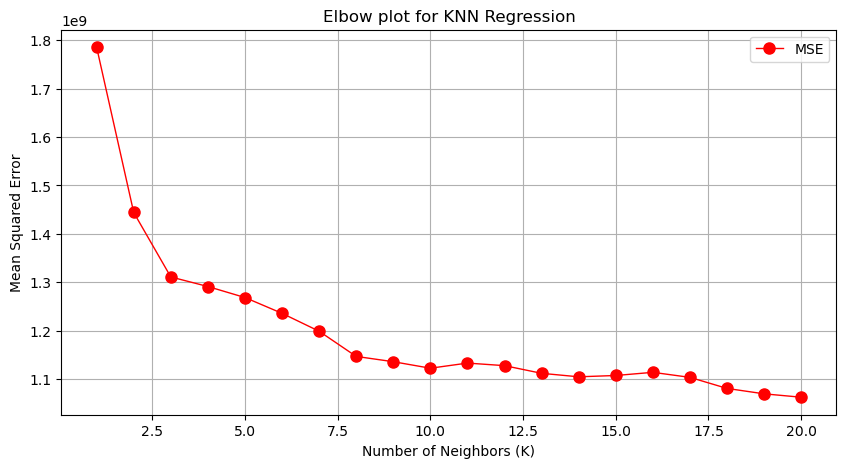

In [103]:
#plot the elbow plot
plt.figure(figsize=(10,5))
plt.plot(k_values,mse_values,marker='o',color='red',linewidth=True,markersize=8,label='MSE')
plt.title("Elbow plot for KNN Regression")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)

plt.show()


In [104]:
# Model 2: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 204308498.00808188
R2 Score: 0.8041712337700486


In [105]:
# model 3: Decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("Decision Tree Mean Squared Error:", mse)
print("Decision Tree R2 Score:", r2)

Decision Tree Mean Squared Error: 515234998.0229653
Decision Tree R2 Score: 0.5061495974712834


In [106]:
#model 4: Random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("Random Forest Mean Squared Error:", mse)
print("Random Forest R2 Score:", r2)

Random Forest Mean Squared Error: 206808381.89435494
Random Forest R2 Score: 0.8017751064334969
